In [1]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv")

# 1. Identify data types of different columns

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1500 non-null   int64  
 1   VendorID               1500 non-null   int64  
 2   tpep_pickup_datetime   1500 non-null   object 
 3   tpep_dropoff_datetime  1500 non-null   object 
 4   passenger_count        1445 non-null   float64
 5   trip_distance          1500 non-null   float64
 6   RatecodeID             1445 non-null   float64
 7   store_and_fwd_flag     1445 non-null   object 
 8   PULocationID           1500 non-null   int64  
 9   DOLocationID           1500 non-null   int64  
 10  payment_type           1500 non-null   object 
 11  extra                  1500 non-null   float64
 12  tip_amount             1500 non-null   float64
 13  tolls_amount           1500 non-null   float64
 14  improvement_surcharge  1500 non-null   float64
 15  cong

# 2. Descriptive statistics of numerical columns

In [6]:
train_df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,10000.000000,9634.000000,10000.000000,9634.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9634.000000,9634.000000
mean,0.729100,1.357276,3.679527,1.450695,132.710800,132.33240,1.940950,6.094658,0.664425,0.979490,29.740157,2.238426,0.161122
std,0.444672,0.883676,4.905798,5.988978,75.789597,75.95944,1.945885,4.438894,2.441070,0.200076,26.256398,0.834189,0.512859
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,-7.500000,0.000713,-26.550000,-1.000000,-129.300000,-2.500000,-1.750000
25%,0.000000,1.000000,1.070000,1.000000,67.000000,68.00000,0.000000,3.466789,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.820000,1.000000,133.000000,132.00000,1.750000,5.208233,0.000000,1.000000,21.360000,2.500000,0.000000
75%,1.000000,1.000000,3.630000,1.000000,198.000000,199.00000,2.500000,7.455228,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,6.000000,71.940000,99.000000,264.000000,264.00000,11.750000,84.032617,32.050000,1.000000,551.000000,2.500000,1.750000


In [7]:
train_df.describe().T[['min','max','mean','50%','75%']]

,min,max,mean,50%,75%
VendorID,0.000000,2.000000,0.729100,1.000000,1.000000
passenger_count,0.000000,6.000000,1.357276,1.000000,1.000000
trip_distance,0.000000,71.940000,3.679527,1.820000,3.630000
RatecodeID,1.000000,99.000000,1.450695,1.000000,1.000000
PULocationID,1.000000,264.000000,132.710800,133.000000,198.000000
DOLocationID,1.000000,264.000000,132.332400,132.000000,199.000000
extra,-7.500000,11.750000,1.940950,1.750000,2.500000
tip_amount,0.000713,84.032617,6.094658,5.208233,7.455228
tolls_amount,-26.550000,32.050000,0.664425,0.000000,0.000000
improvement_surcharge,-1.000000,1.000000,0.979490,1.000000,1.000000


# 3. Identify and handle the missing values
* Note: Missing values are handled using SimpleImputer, where numerical features are imputed using the mean and categorical features using the most frequent value (mode), as implemented in Section 7.

In [8]:
train_df.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

# 4. Identify and handle duplicates

In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
train_df = train_df.drop_duplicates()

# 5. Identify outliers
* Outliers were identified using boxplots. Instead of removing them, I retained them to preserve real-world patterns.
* Tree based models like Decision Trees, Random Forest, and Gradient Boosting are generally robust to outliers, which makes them suitable for this dataset, as implemented in Section 11.

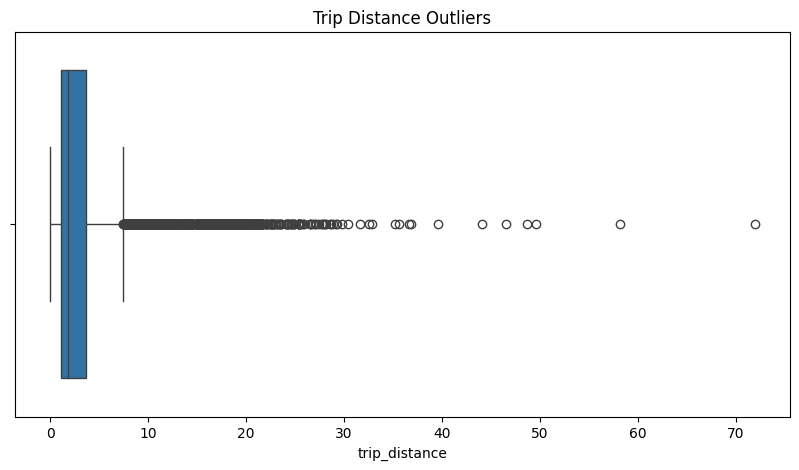

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train_df['trip_distance'])
plt.title("Trip Distance Outliers")
plt.show()

# 6. Visualizations

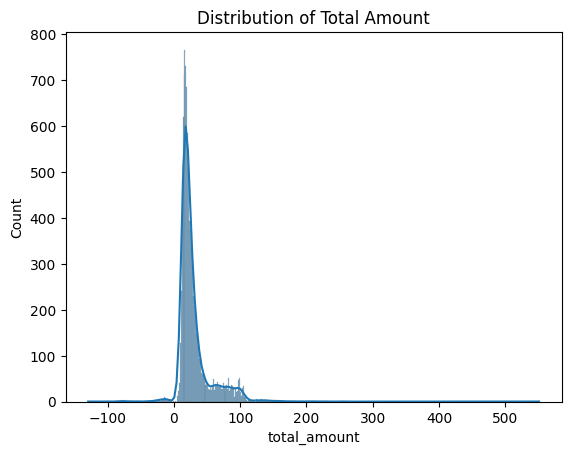

In [12]:
sns.histplot(train_df['total_amount'], kde=True)
plt.title("Distribution of Total Amount")
plt.show()

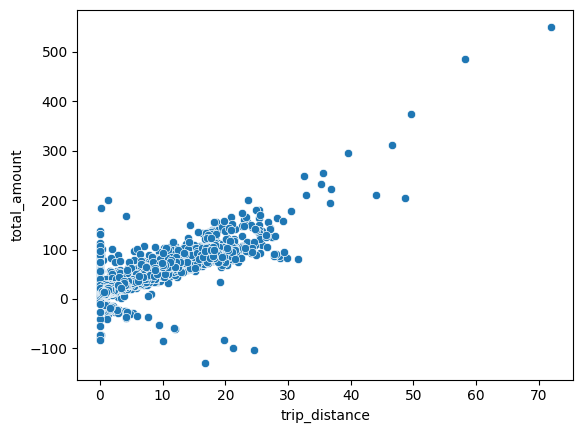

In [13]:
sns.scatterplot(x='trip_distance', y='total_amount', data=train_df)
plt.show()

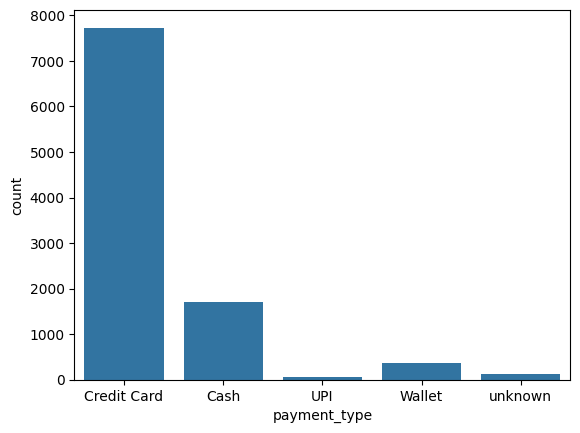

In [14]:
sns.countplot(x='payment_type', data=train_df)
plt.show()

**6.1. Insight:**
*  Most trips fall in lower fare range, indicating short-distance travel dominates.

# 7. Scale Numerical features and Encode Categorical features

* Preprocessing pickup time and drop off time to find the trip duration.
* Numerical features are scaled using StandardScaler to normalize feature ranges.
* Categorical variables are encoded using OneHotEncoder to prevent introducing ordinal relationships.

In [15]:
def preprocess_datetime(df):
    df = df.copy()
    
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['trip_duration'] = (
        (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
        .dt.total_seconds() / 60
    )
    
    return df.drop(['tpep_pickup_datetime', 'tpep_dropoff_datetime'], axis=1)

train_df = preprocess_datetime(train_df)
test_df = preprocess_datetime(test_df)


In [16]:
X = train_df.drop('total_amount', axis=1)
y = train_df['total_amount']

X_test = test_df.copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
num_cols = [
    'passenger_count', 'trip_distance', 'extra',
    'tip_amount', 'tolls_amount',
    'improvement_surcharge', 'congestion_surcharge',
    'Airport_fee', 'pickup_hour', 'trip_duration'
]

cat_cols = [
    'store_and_fwd_flag', 'payment_type',
    'PULocationID', 'DOLocationID', 'RatecodeID'
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 8. Model Building

In [18]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoost": GradientBoostingRegressor(),
    "SVR": SVR()
}

In [19]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    
    results[name] = r2_score(y_val, preds)

results

{'Linear': 0.854331271453171,
 'Ridge': 0.8546109941040323,
 'Lasso': 0.8215691836421195,
 'DecisionTree': 0.9295906128292848,
 'RandomForest': 0.8978131252594204,
 'GradientBoost': 0.9125909339959233,
 'SVR': 0.624964447668673}

# 9. Hyperparameter Tuning

9.1 Random Forest Regressor

In [20]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15]
}

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

grid = GridSearchCV(rf_pipe, param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'model__max_depth': 15, 'model__n_estimators': 200}

9.2 Decision Tree Regressor

In [21]:
param_grid = {
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor())
])

grid = GridSearchCV(dt_pipe, param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'model__max_depth': 10, 'model__min_samples_split': 10}

9.3 Gradient Boosting Regressor

In [22]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

gbr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor())
])

grid = GridSearchCV(gbr_pipe, param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'model__learning_rate': 0.05,
 'model__max_depth': 5,
 'model__n_estimators': 200}

# 10. Comparison of model performances

In [23]:
pd.DataFrame(results.items(), columns=["Model","R2 Score"]).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
3,DecisionTree,0.929591
5,GradientBoost,0.912591
4,RandomForest,0.897813
1,Ridge,0.854611
0,Linear,0.854331
2,Lasso,0.821569
6,SVR,0.624964


# 11. Final Model
* Tree based models like Decision Trees, Random Forest, and Gradient Boosting are generally robust to outliers, which makes them suitable for this dataset.

In [24]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

In [25]:
model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['passenger_count',
                                                   'trip_distance', 'extra',
                                                   'tip_amount', 'tolls_amount',
                                                   'improvement_surcharge',
                                                   'congestion_surcharge',
                                                   'Airport_fee', 'pickup_hour',
                                                   'trip_duration']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['store_and_fwd_flag',
                                                   'payment_type',
                                                   'PULocationID',
                                                   'DOLocationID',
                                                   'RatecodeID'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [26]:
y_pred = model.predict(X_test)

In [27]:
submission = pd.DataFrame({
    "id": X_test['id'],
    "total_amount": y_pred
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission file ready!")

Submission file ready!
